In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET_COL = "gb"
ID_COL = "id"

In [6]:
df = pd.read_csv("train_df.csv", sep='\t')

EDA

In [7]:
df.shape

(26824, 554)

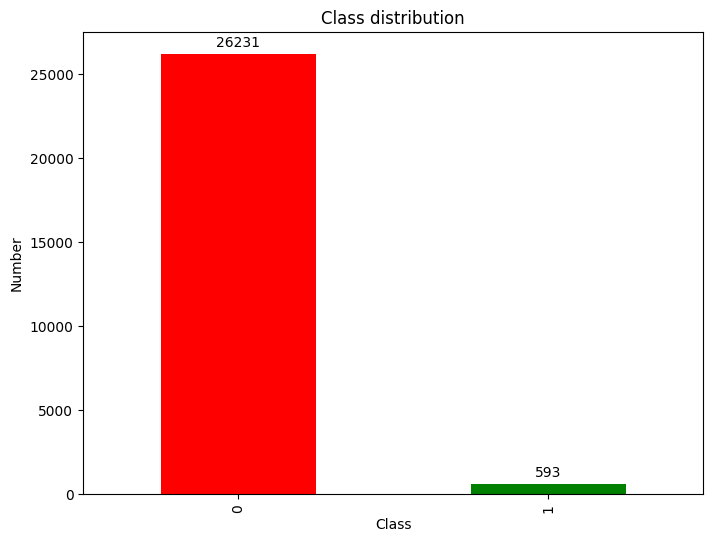

In [8]:
target_counts = df['gb'].value_counts().sort_index()

ax = target_counts.plot(kind = 'bar', color = ['red', 'green'], figsize=(8,6))
plt.title('Class distribution')
plt.xlabel('Class')
plt.ylabel('Number')

for i in ax.containers:
    ax.bar_label(i, padding=3)

plt.show()

In [9]:
missing_pct = df.isnull().mean() * 100
empty_cols = missing_pct[missing_pct == 100].sort_values(ascending=False)
empty_cols

num_23     100.0
num_66     100.0
num_150    100.0
num_152    100.0
num_242    100.0
num_250    100.0
num_258    100.0
num_266    100.0
num_342    100.0
num_365    100.0
num_375    100.0
num_392    100.0
dtype: float64

In [ ]:
def detect_duplicate_columns(df):
    duplicates = {}
    seen = set()
    cols = df.columns
    
    for i, col in enumerate(cols):
        if col in seen:
            continue
        same = [c for c in cols[i+1:] if df[col].equals(df[c])]
        if same:
            duplicates[col] = same
            seen.update(same)
            
    return duplicates

detect_duplicate_columns(df)

{'num_19': ['num_113', 'num_267', 'num_330', 'num_379', 'num_412'],
 'num_23': ['num_66',
  'num_150',
  'num_152',
  'num_242',
  'num_250',
  'num_258',
  'num_266',
  'num_342',
  'num_365',
  'num_375',
  'num_392'],
 'cat_7': ['cat_13',
  'cat_30',
  'cat_42',
  'cat_53',
  'cat_66',
  'cat_79',
  'cat_86',
  'cat_122',
  'cat_127'],
 'num_57': ['num_321'],
 'num_68': ['num_69', 'num_83', 'num_117'],
 'num_71': ['num_265'],
 'num_92': ['num_264', 'num_270', 'num_380', 'num_411'],
 'num_110': ['num_111', 'num_331'],
 'num_112': ['num_372'],
 'num_189': ['num_248'],
 'num_246': ['num_338', 'num_406', 'num_409'],
 'num_268': ['num_269'],
 'num_307': ['num_312'],
 'num_371': ['num_405']}

In [14]:
print("=" * 60)
print("2. NUMERICAL FEATURES ANALYSIS")
print("=" * 60)

# Extract numerical columns dynamically
num_df = df.filter(like='num_')
print(f"Total numerical features found: {num_df.shape[1]}")

# Missing values profiling
missing_pct = num_df.isnull().mean() * 100
print(f"  • 100% empty columns:        { (missing_pct == 100).sum() }")
print(f"  • Heavy missingness (>=50%): { ((missing_pct >= 50) & (missing_pct < 100)).sum() }")

# Outliers check via IQR (only where data exists)
outlier_features_count = 0
for col in num_df.columns:
    series = num_df[col].dropna()
    if len(series) < 50: 
        continue
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr > 0:
        pct_outliers = ((series < q1 - 1.5 * iqr) | (series > q3 + 1.5 * iqr)).mean()
        if pct_outliers > 0.05:
            outlier_features_count += 1
print(f"  • Features with >5% outliers: {outlier_features_count}")

# Low variance / Constant check
low_var = [c for c in num_df.columns if num_df[c].dropna().var(ddof=0) < 0.01]
print(f"  • Quasi-constant features:   {len(low_var)}")

2. NUMERICAL FEATURES ANALYSIS
Total numerical features found: 416
  • 100% empty columns:        12
  • Heavy missingness (>=50%): 153
  • Features with >5% outliers: 274
  • Quasi-constant features:   7


In [15]:
print("=" * 60)
print("3. CATEGORICAL FEATURES ANALYSIS")
print("=" * 60)

# Extract categorical columns dynamically
cat_df = df.filter(like='cat_')
print(f"Total categorical features found: {cat_df.shape[1]}")

# Cardinality profiling
cat_nunique = cat_df.nunique()
print(f"  • Median unique values:       {cat_nunique.median():.0f}")
print(f"  • High cardinality (>50 val): { (cat_nunique > 50).sum() }")

3. CATEGORICAL FEATURES ANALYSIS
Total categorical features found: 135
  • Median unique values:       3
  • High cardinality (>50 val): 5


In [17]:
print("=" * 60)
print("4. STRUCTURAL INTEGRITY & RELATIONSHIPS (NaN-Safe)")
print("=" * 60)

# Check for completely identical rows
print(f"Identical rows: {df.duplicated().sum()}")

# Strict column duplicate check:
# To prevent sparse columns (mostly NaN) from causing false positives,
# we only evaluate columns that contain a meaningful amount of actual data.
min_valid_values = 50
robust_cols = [c for c in df.columns if df[c].notnull().sum() >= min_valid_values]

col_dups = 0
for i, c1 in enumerate(robust_cols):
    for c2 in robust_cols[i+1:]:
        if df[c1].equals(df[c2]):
            col_dups += 1

print(f"Identical column pairs (with >= {min_valid_values} valid values): {col_dups}")

# Robust correlation check for numericals (avoiding ghost correlations)
num_df_clean = df.filter(like='num_').dropna(how='all', axis=1)
corr_matrix = num_df_clean.corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_count = 0
for i in range(len(upper_tri.index)):
    for j in range(len(upper_tri.columns)):
        if upper_tri.iloc[i, j] > 0.95:
            c1, c2 = upper_tri.index[i], upper_tri.columns[j]
            # Ensure the correlation is based on actual overlapping data, not empty rows
            if df[[c1, c2]].dropna().shape[0] >= min_valid_values:
                high_corr_count += 1

print(f"Highly correlated pairs (r > 0.95, shared rows >= {min_valid_values}): {high_corr_count}")

4. STRUCTURAL INTEGRITY & RELATIONSHIPS (NaN-Safe)
Identical rows: 0
Identical column pairs (with >= 50 valid values): 91
Highly correlated pairs (r > 0.95, shared rows >= 50): 702
